<table width="100%" style="border:none; border-collapse:collapse;">
<tr style="border:none;">
<td width="150" style="border:none;"></td>
<td align="center" style="border:none;">
    <h1>Tarea Semanal 1</h1>
    <h2>Teoría de los Circuitos II - R4052</h2>
    <h3>Fabián Alexander Iturrizaga Meza</h3>
    <br>
    <b>Docentes</b><br>
    Profesor: Mariano Llamedo Soria<br>
    Jefe de TPs: César Fuoco<br>
    Ayudante de TPs: David Moharos
</td>
<td width="150" align="right" style="border:none; vertical-align:top;"><img src="./img/logo_UTN.svg" width="150" /></td>
</tr>
</table>

***

## Consigna

<img src="./img/consigna.png" width="800" />

## Indice

1. [Punto 1 — Obtención de T(s), diagramas de módulo, fase y polos/ceros](#Punto-1-—-Resolución-manuscrita)
2. [Punto 2 — Tipo de filtro y utilidad](#Punto-2-—-Tipo-de-filtro-y-utilidad)
3. [Punto 3 — Normalización en impedancia y frecuencia](#Punto-3-—-Normalización-en-impedancia-y-frecuencia)
4. [Punto 4 — Simulación numérica en Python](#Punto-4-—-Simulación-numérica-de-la-transferencia-normalizada-en-Python)
5. [Punto 5 — Red normalizada](#Punto-5-—-Red-normalizada)
6. [Punto 6 — Simulación en LTSpice](#Punto-6-—-Simulación-en-LTSpice)

**Bonus:**
- [Verificación simbólica con SymPy](#Bonus-—-Verificación-simbólica-con-SymPy)
- [Comparación con Ejercicio 7 de la Guía de TPs](#Bonus-—-Comparación-con-el-Ejercicio-7-de-la-Guía-de-TPs)


***

## Punto 1 — Resolución manuscrita

Originales: `p1_hoja_1.jpeg` a `p1_hoja_4.jpeg` en [img/](./img/)

<img src="./img/p1_hoja_1.jpeg" width="450" />

<img src="./img/p1_hoja_2.jpeg" width="450" />

<img src="./img/p1_hoja_3.jpeg" width="450" />

<img src="./img/p1_hoja_4.jpeg" width="450" />


In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import sympy as sp
from scipy import signal as sig
import matplotlib.pyplot as plt

# PyTC2: librería para Teoría de Circuitos II
from pytc2.sistemas_lineales import bodePlot, pzmap, analyze_sys
from pytc2.general import print_subtitle, print_latex, a_equal_b_latex_s

# Configuración de gráficos
plt.rcParams['figure.figsize'] = [12, 4]
plt.rcParams['figure.dpi'] = 150
plt.rcParams.update({'font.size': 11})


***

### Desarrollo de la función de transferencia

Partimos de las dos ecuaciones del circuito:

$$
\frac{V_i - V_x}{R_1} = \frac{V_x - V_0}{R_2} \quad \mathbf{(1)}
$$

$$
(V_i - V_x)sC = \frac{V_x}{R_3} \quad \mathbf{(2)}
$$

La idea es resolver primero $\mathbf{(2)}$ para obtener \(V_x\) en función de \(V_i\), y luego reemplazar ese resultado en $\mathbf{(1)}$.

---

### 1) Despeje de \(V_x\) a partir de $\mathbf{(2)}$

Partimos de $\mathbf{(2)}$:

$$
(V_i - V_x)sC = \frac{V_x}{R_3}
$$

Distribuyendo:

$$
V_i sC - V_x sC = \frac{V_x}{R_3}
$$

Agrupando los términos con \(V_x\):

$$
V_i sC = V_x\left(sC + \frac{1}{R_3}\right)
$$

Despejando \(V_x\):

$$
V_x = \frac{V_i sC}{sC + \frac{1}{R_3}}
$$

Multiplicando numerador y denominador por \(R_3\):

$$
V_x = V_i \frac{sCR_3}{sCR_3 + 1} \quad \mathbf{(3)}
$$

---

### 2) Sustitución de $\mathbf{(3)}$ en $\mathbf{(1)}$

Tomamos $\mathbf{(1)}$ y la expandimos:

$$
\frac{V_i}{R_1} - \frac{V_x}{R_1} = \frac{V_x}{R_2} - \frac{V_0}{R_2}
$$

Sustituyendo $\mathbf{(3)}$:

$$
\frac{V_i}{R_1} - \frac{1}{R_1}\left(V_i \frac{sCR_3}{sCR_3 + 1}\right)
=
\frac{1}{R_2}\left(V_i \frac{sCR_3}{sCR_3 + 1}\right) - \frac{V_0}{R_2}
$$

Factorizando \(V_i\):

$$
V_i\left(
\frac{1}{R_1}
-
\frac{sCR_3}{(sCR_3+1)R_1}
-
\frac{sCR_3}{(sCR_3+1)R_2}
\right)
=
-\frac{V_0}{R_2}
$$

Llevando todo a un denominador común:

$$
V_i\left(
\frac{(sCR_3+1)R_2 - sCR_3R_2 - sCR_3R_1}
{(sCR_3+1)R_1R_2}
\right)
=
-\frac{V_0}{R_2}
$$

Simplificando el numerador:

$$
V_i\left(
\frac{R_2 - sCR_3R_1}
{(sCR_3+1)R_1R_2}
\right)
=
-\frac{V_0}{R_2}
$$

Multiplicando ambos lados por \(R_2\):

$$
V_i\left(
\frac{R_2 - sCR_3R_1}
{(sCR_3+1)R_1}
\right)
=
- V_0
$$

Multiplicando por \(-1\):

$$
V_0
=
V_i\left(
\frac{sCR_3R_1 - R_2}
{(sCR_3+1)R_1}
\right)
$$

Por lo tanto, la función de transferencia es:

$$
\frac{V_0}{V_i}
=
\frac{sCR_3R_1 - R_2}
{(sCR_3+1)R_1}
$$

Expandiendo el denominador:

$$
\frac{V_0}{V_i}
=
\frac{sCR_3R_1 - R_2}
{sCR_3R_1 + R_1}
$$

Y dividiendo numerador y denominador por \(CR_3R_1\):

$$
\frac{V_0}{V_i}
=
\frac{s - \frac{R_2}{CR_3R_1}}
{s + \frac{1}{CR_3}} \quad \mathbf{(4)}
$$

---

### Caso particular: $\frac{R_2}{R_1}=1$

Si \(R_2 = R_1\), reemplazando en $\mathbf{(4)}$:

$$
\large
\frac{V_0}{V_i}
=
\frac{s - \frac{1}{R_3 C}}
{s + \frac{1}{R_3 C}} \quad \mathbf{(5)}
$$

***

### Cálculo analítico de módulo y fase

Partimos de $\mathbf{(5)}$ evaluada en $s = j\omega$:

$$
H(j\omega) = \frac{j\omega - \frac{1}{R_3 C}}{j\omega + \frac{1}{R_3 C}} \quad \mathbf{(6)}
$$

Para simplificar, definimos $X = \frac{1}{R_3 C}$:

$$
H(j\omega) = \frac{j\omega - X}{j\omega + X} \quad \mathbf{(7)}
$$

---

#### Módulo

$$
|H(j\omega)| = \frac{\sqrt{(-X)^2 + \omega^2}}{\sqrt{X^2 + \omega^2}} = \frac{\sqrt{X^2 + \omega^2}}{\sqrt{X^2 + \omega^2}} = 1 \quad \forall \omega
\qquad \Longrightarrow \qquad \boxed{|H(j\omega)| = 1} \quad \mathbf{(8)}
$$

---

#### Fase

En un primer intento, calculamos la fase de $\mathbf{(7)}$ como diferencia de argumentos de numerador y denominador:

$$
\phi_{H(j\omega)} = \arctan\!\left(\frac{-\omega}{X}\right) - \arctan\!\left(\frac{\omega}{X}\right) \quad \mathbf{(9)}
$$

Como $\arctan$ es impar, $\arctan(-x) = -\arctan(x)$:

$$
\phi_{H(j\omega)} = -\arctan\!\left(\frac{\omega}{X}\right) - \arctan\!\left(\frac{\omega}{X}\right) = -2\arctan\!\left(\frac{\omega}{X}\right) \quad \mathbf{(10)}
$$

Pero $\mathbf{(10)}$ es **incorrecto** porque no tiene en cuenta el cuadrante del numerador. Para entender por qué, veamos el comportamiento de las funciones $\tan$ y $\arctan$:

<div align="center">
<img src="./img/grafico_tan.png" width="450" />
</div>
<div align="center">
<img src="./img/grafico_arctan.png" width="450" />
</div>


**Corrección por cuadrante:** El numerador $-X + j\omega$ tiene parte real negativa y parte imaginaria positiva, por lo tanto es un complejo del **2do cuadrante**. Sin embargo, como se ve en el gráfico de la derecha, $\arctan$ solo devuelve valores en $\left(-\frac{\pi}{2},\, \frac{\pi}{2}\right)$, es decir, ángulos del 1er y 4to cuadrante.

Del gráfico de la izquierda vemos que $\tan(\alpha) = \tan(\alpha + \pi)$, por lo tanto para obtener el ángulo correcto del 2do cuadrante debemos sumar $\pi$ al argumento del numerador:

$$
\phi_{H(j\omega)} = \left[\pi + \arctan\!\left(\frac{-\omega}{X}\right)\right] - \arctan\!\left(\frac{\omega}{X}\right) \quad \mathbf{(11)}
$$

Aplicando nuevamente que $\arctan$ es impar:

$$
\phi_{H(j\omega)} = \pi - \arctan\!\left(\frac{\omega}{X}\right) - \arctan\!\left(\frac{\omega}{X}\right) = \pi - 2\arctan\!\left(\frac{\omega}{X}\right) \quad \mathbf{(12)}
$$

Reemplazando $X = \frac{1}{R_3 C}$ en $\mathbf{(12)}$:

$$
\boxed{\phi_{H(j\omega)} = \pi - 2\arctan\!\left(\omega \, R_3 \, C\right)} \quad \mathbf{(13)}
$$

**Verificación de $\mathbf{(13)}$:**
- En $\omega = 0$: $\phi = \pi - 0 = \pi$ (es decir $180°$, consistente con $H(0) = -1$)
- En $\omega \to \infty$: $\phi = \pi - 2 \cdot \frac{\pi}{2} = 0°$
- En $\omega = X = \frac{1}{R_3C}$: $\phi = \pi - 2 \cdot \frac{\pi}{4} = \frac{\pi}{2}$ (es decir $90°$)

Entonces módulo y fase nos dieron como los gráficos esperados.

***

## Simulación en Python

### Diagramas de Módulo, Fase y Polos/Ceros para $\frac{R_2}{R_1} = 1$

Cuando el ratio $\frac{R_2}{R_1}$ es unitario, la transferencia general se reduce a:

$$
H(s) = \frac{s - \frac{1}{R_3 C}}{s + \frac{1}{R_3 C}}
$$

Definiendo $\omega_0 = \frac{1}{R_3 C}$:

$$
\boxed{H(s) = \frac{s - \omega_0}{s + \omega_0}}
$$

Se trata de un **pasa-todo de primer orden**. Sus propiedades esperadas son:
- **Módulo:** $|H(j\omega)| = 1$ para toda frecuencia (0 dB constante).
- **Fase:** Varía de $180°$ a $0°$, pasando por $90°$ en $\omega = \omega_0$.
- **Polos y ceros:** Un polo real en $s = -\omega_0$ y un cero real en $s = +\omega_0$, simétricos respecto al eje imaginario.

In [2]:
# Definición de la transferencia para R2/R1 = 1 (ratio unitario)
# H(s) = (s - w0) / (s + w0)  con w0 = 1/(R3*C)
# Normalizamos con w0 = 1 rad/s

w0 = 1  # frecuencia normalizada: w0 = 1/(R3*C)

num = np.array([1, -w0])   # s - w0
den = np.array([1,  w0])   # s + w0

H_ap = sig.TransferFunction(num, den)

print_subtitle('Transferencia Pasa-todo con R2/R1 = 1')
print(f'H(s) = (s - {w0}) / (s + {w0})')
print(f'Polo:  s = {H_ap.poles}')
print(f'Cero:  s = {H_ap.zeros}')

#### Transferencia Pasa-todo con R2/R1 = 1

H(s) = (s - 1) / (s + 1)
Polo:  s = [-1.]
Cero:  s = [1.]


### Diagrama de Módulo y Fase (Bode)

Para un pasa-todo de primer orden, el módulo es constante e igual a 0 dB para toda frecuencia, y la fase recorre de $0°$ a $-180°$.

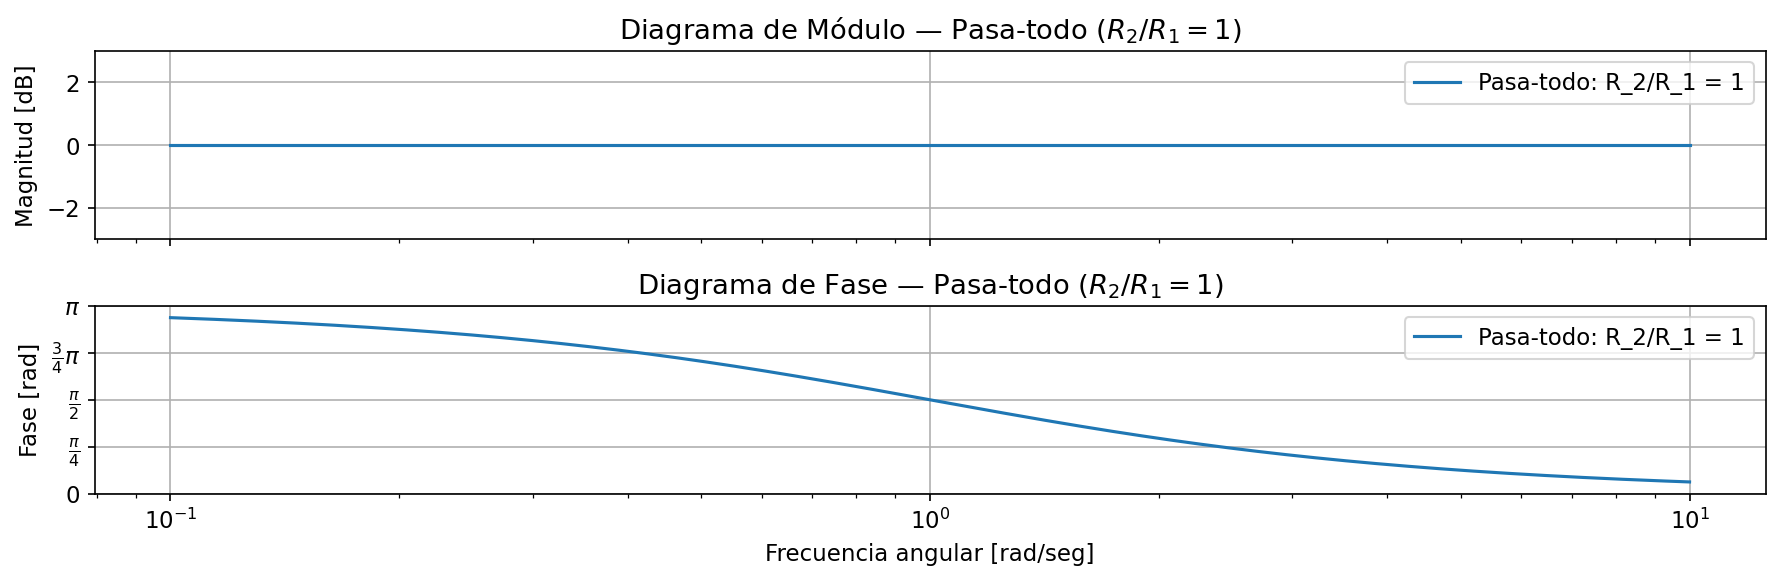

In [3]:
# Diagrama de Bode: Módulo y Fase
_, axes_hdl = bodePlot(H_ap, filter_description='Pasa-todo: R_2/R_1 = 1')

plt.sca(axes_hdl[0])
plt.title('Diagrama de Módulo — Pasa-todo ($R_2/R_1 = 1$)')
plt.ylim([-3, 3])

plt.sca(axes_hdl[1])
plt.title('Diagrama de Fase — Pasa-todo ($R_2/R_1 = 1$)')

plt.tight_layout()
plt.show()

### Diagrama de Polos y Ceros

El sistema tiene:
- **Un polo** en $s = -\omega_0 = -1$ (semiplano izquierdo, sistema estable)
- **Un cero** en $s = +\omega_0 = +1$ (semiplano derecho, fase no mínima)

La simetría polo/cero respecto al eje imaginario es la característica fundamental de un pasa-todo.

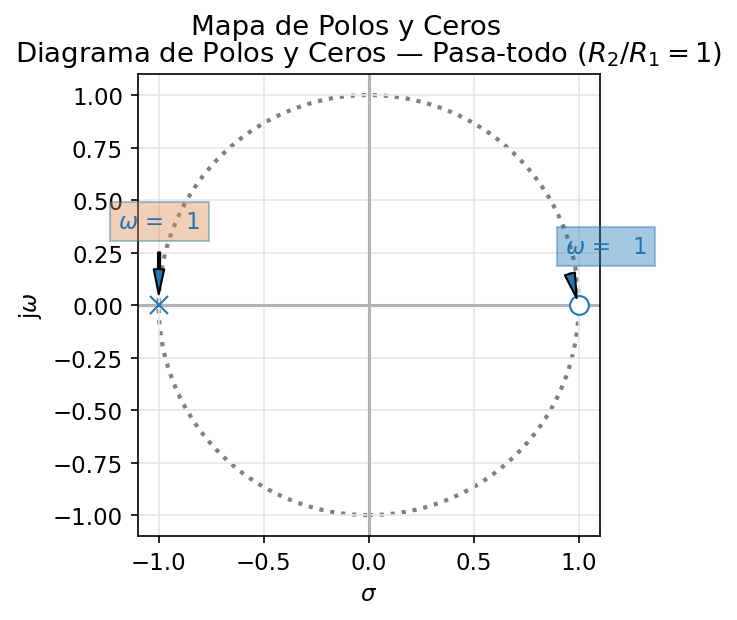

In [4]:
# Diagrama de Polos y Ceros
pzmap(H_ap, filter_description='Pasa-todo: R_2/R_1 = 1', annotations=True)
plt.title('Diagrama de Polos y Ceros — Pasa-todo ($R_2/R_1 = 1$)')
plt.legend().remove()
plt.show()

---

### Anexo Punto 1 — Verificación simbólica sin asumir RN

Siguiendo el enfoque del notebook [Sallen-Key análisis simbólico (1.c)](https://github.com/marianux/tc2/blob/main/Sallen-Key%20analisis%20simbolico.ipynb), se plantean las ecuaciones del circuito **sin asumir realimentación negativa**, usando la ecuación del opamp ideal $(V^+ - V^-) \cdot A(s) = V_o$ y luego tomando $A(s) \to \infty$.


In [5]:
# Verificación sin asumir RN, opamp ideal

s_sym = sp.symbols('s', complex=True)
Vi_s, Vo_s, Va_s, Vinv_s = sp.symbols('Vi, Vo, Va, Vinv')
R1_s, R2_s, R3_s, C_s, As_s = sp.symbols('R1, R2, R3, C, As', positive=True)

aa = sp.solve([
    (Vi_s - Vinv_s)/R1_s - (Vinv_s - Vo_s)/R2_s,
    (Vi_s - Va_s)*s_sym*C_s - Va_s/R3_s,
    (Va_s - Vinv_s)*As_s - Vo_s
], [Vo_s, Vi_s, Vinv_s, Va_s])

T_gen = aa[Vo_s] / aa[Vi_s]

print_subtitle('Transferencia con A(s) genérica')
print_latex(a_equal_b_latex_s(r'\frac{V_o}{V_i}', sp.simplify(T_gen)))

# Opamp ideal: A(s) → ∞
T_ideal = sp.simplify(sp.limit(T_gen, As_s, sp.oo))

print_subtitle('Opamp ideal: A(s) → ∞')
print_latex(a_equal_b_latex_s(r'\frac{V_o}{V_i}', T_ideal))

# Caso R2 = R1
T_ap = sp.simplify(T_ideal.subs(R2_s, R1_s))

print_subtitle('Con R2 = R1')
print_latex(a_equal_b_latex_s(r'\frac{V_o}{V_i}\bigg|_{R_2=R_1}', T_ap))


#### Transferencia con A(s) genérica

<IPython.core.display.Math object>

#### Opamp ideal: A(s) → ∞

<IPython.core.display.Math object>

#### Con R2 = R1

<IPython.core.display.Math object>

El resultado coincide con la transferencia obtenida en $\mathbf{(5)}$, lo que confirma que el circuito está efectivamente **realimentado de forma negativa**.


***

## Punto 2 — Tipo de filtro y utilidad

### ¿De qué tipo de filtro se trata?

El circuito implementa un **filtro pasa-todo (allpass) de primer orden**. Su característica principal es que **no modifica la amplitud** de ninguna componente frecuencial de la señal ($|H(j\omega)| = 1\;\forall\;\omega$), sino que **solo modifica la fase**. Por esta razón, el concepto de frecuencia de corte no tiene sentido para este tipo de filtro [1, p.76].

La transferencia obtenida en $\mathbf{(5)}$:

$$H(s) = \frac{s - \omega_0}{s + \omega_0}$$

tiene un **cero en el semiplano derecho** ($s = +\omega_0$) y un **polo en el semiplano izquierdo** ($s = -\omega_0$), simétricos respecto al eje imaginario. Esta es la firma de un sistema de **fase no mínima**. En general, la transferencia de un allpass se construye como [1, Eq. 11.4, p.434] [2, Eq. 3.44, p.53]:

$$T_{AP}(s) = \frac{E(-s)}{E(s)}$$

donde $E(s)$ es un polinomio de Hurwitz (todos sus ceros en el semiplano izquierdo). El numerador se obtiene reemplazando $s$ por $-s$, lo que refleja los ceros al semiplano derecho, garantizando $|T_{AP}(j\omega)| = 1$.

---

### Relación con filtros de fase mínima

Una misma respuesta en magnitud $|H(j\omega)|$ puede corresponder a distintas fases. Un filtro de **fase mínima** es aquel cuyos ceros de transmisión están en el semiplano izquierdo, produciendo la menor fase posible para un $|H(j\omega)|$ dado [2, Sec. 3.6, p.51].

Cualquier filtro de fase **no mínima** se puede descomponer como el producto de un filtro de fase mínima y una red pasa-todo [2, Eq. 3.45, p.53]:

$$H_{\text{no-min}}(s) = H_{\text{min}}(s) \cdot H_{ap}(s)$$

Esto significa que el pasa-todo es el "bloque" que convierte cualquier sistema de fase mínima en uno de fase no mínima, sin alterar la magnitud. Esta propiedad es fundamental en la teoría de filtros.

---

### Realizaciones circuitales

Existen varias formas de implementar un allpass de primer orden:

- **Activa con opamp [1, Fig. 3.34, p.96 y Fig. 11.6, p.436]:** Dos variantes — no inversora ($K = +1$, fase de $180°$ a $0°$) e inversora ($K = -1$, fase de $0°$ a $-180°$): $T_1(s) = \pm\frac{s - 1/(RC)}{s + 1/(RC)}$. El circuito de esta tarea corresponde a esta categoría.

- **Pasiva con red lattice/bridge [1, Fig. 3.13, p.75]:** Estructura capaz de generar ceros en el semiplano derecho. Con resistores iguales y un capacitor: $T(s) = \frac{1}{2}\frac{1 - sCR}{1 + sCR}$, allpass con ganancia $1/2$.

- **Lattice simétrica de resistencia constante [1, Sec. 13.6, p.524-525]:** Red donde $Z_1 \cdot Z_2 = R_0^2$, cascadeable sin buffers intermedios.

---

### Utilidades y aplicaciones

1. **Ecualización de retardo de grupo [1, Cap. 11, p.432-438]:** Aplicación principal. Cuando un filtro (Butterworth, Chebyshev, etc.) introduce un retardo de grupo no constante, se conecta un allpass **en cascada** para aplanar el retardo total sin alterar la magnitud [1, Fig. 11.3, p.434]:

$$D(\omega) = D_M(\omega) + D_{AP}(\omega) = D_0 \quad (\text{constante})$$

2. **Filtros de retardo [1, Sec. 10.7, p.422-428]:** Cascadas de secciones allpass de 1er y 2do orden permiten implementar filtros Bessel-Thomson con retardo constante. El retardo de grupo de un allpass de primer orden es [1, Eq. 11.7, p.435]:

$$D_1(\omega) = \frac{2/\sigma_1}{1 + (\omega/\sigma_1)^2}$$

con máximo en $\omega = 0$ y $\sigma_1 = 1/(RC)$ como parámetro de ajuste.

3. **Generación de sistemas polifásicos [1, Example 3.8, p.98]:** Redes que generan señales de igual magnitud pero desfasadas (ej: $120°$ para sistemas trifásicos).

---

### Referencias

*[1] Schaumann, R. & Van Valkenburg, M.E. — Design of Analog Filters. Oxford University Press, 2001. ISBN 0-19-511877-4.*

*[2] Cogollos Borrás, S. — Fundamentos de la Teoría de Filtros. Editorial Universitat Politècnica de València, 2016. ISBN 978-84-9048-443-2.*

*Las referencias de página corresponden a las ediciones indicadas.*


***

## Punto 3 — Normalización en impedancia y frecuencia

### Resolución manuscrita

Originales: `p3_hoja_1.jpg` y `p3_hoja_2.jpg` en [img/](./img/)

<img src="./img/p3_hoja_1.jpg" width="450" />

<img src="./img/p3_hoja_2.jpg" width="450" />


### Desarrollo

Partimos de la transferencia $\mathbf{(5)}$ con $\frac{R_2}{R_1} = 1$:

$$
H(s) = \frac{s - \frac{1}{R_3 C}}{s + \frac{1}{R_3 C}}
$$

Los componentes relevantes son $R_3$ y $C$ (ya que $R_1$ y $R_2$ se cancelaron al imponer el ratio unitario).

---

#### Fórmulas de normalización

Recordamos las fórmulas para normalizar en impedancia ($\Omega_z$) y frecuencia ($\Omega_\omega$):

$$
R' = \frac{R}{\Omega_z} \qquad C' = C \cdot \Omega_z \cdot \Omega_\omega \qquad L' = \frac{L \cdot \Omega_\omega}{\Omega_z}
$$

donde $\Omega_z$ y $\Omega_\omega$ son la norma de impedancia y la norma de frecuencia respectivamente.

---

#### Elección de normas

$$
\Omega_\omega = \omega_0 = \frac{1}{R_3 C}
$$

$$
\Omega_z = R_3
$$

---

#### Componentes normalizados

$$
R_3' = \frac{R_3}{\Omega_z} = \frac{R_3}{R_3} = 1
$$

$$
C' = C \cdot \Omega_z \cdot \Omega_\omega = C \cdot R_3 \cdot \frac{1}{R_3 C} = 1
$$

Como $R_2 = R_1$ y su ratio debe conservarse: $R_1' = R_2' = 1$.

---

#### Transferencia normalizada

Realizamos el cambio de variable de frecuencia:

$$
s' = \frac{s}{\omega_0} \quad \Longrightarrow \quad s = s' \cdot \omega_0 = s' \cdot \frac{1}{R_3 C}
$$

Sustituyendo en $\mathbf{(5)}$:

$$
H(s') = \frac{s' \cdot \frac{1}{R_3 C} - \frac{1}{R_3 C}}{s' \cdot \frac{1}{R_3 C} + \frac{1}{R_3 C}}
= \frac{\cancel{\frac{1}{R_3 C}}\left(s' - 1\right)}{\cancel{\frac{1}{R_3 C}}\left(s' + 1\right)}
$$

$$
\boxed{H(s') = \frac{s' - 1}{s' + 1}} \quad \text{Transferencia normalizada}
$$

El circuito normalizado queda con $R_1' = R_2' = R_3' = 1$ y $C' = 1$.

***

## Punto 4 — Simulación numérica de la transferencia normalizada en Python


In [6]:
# Transferencia normalizada: H(s') = (s' - 1) / (s' + 1)
num_n = np.array([1, -1])
den_n = np.array([1,  1])

H_norm = sig.TransferFunction(num_n, den_n)
display(H_norm)

TransferFunctionContinuous(
array([ 1., -1.]),
array([1., 1.]),
dt: None
)

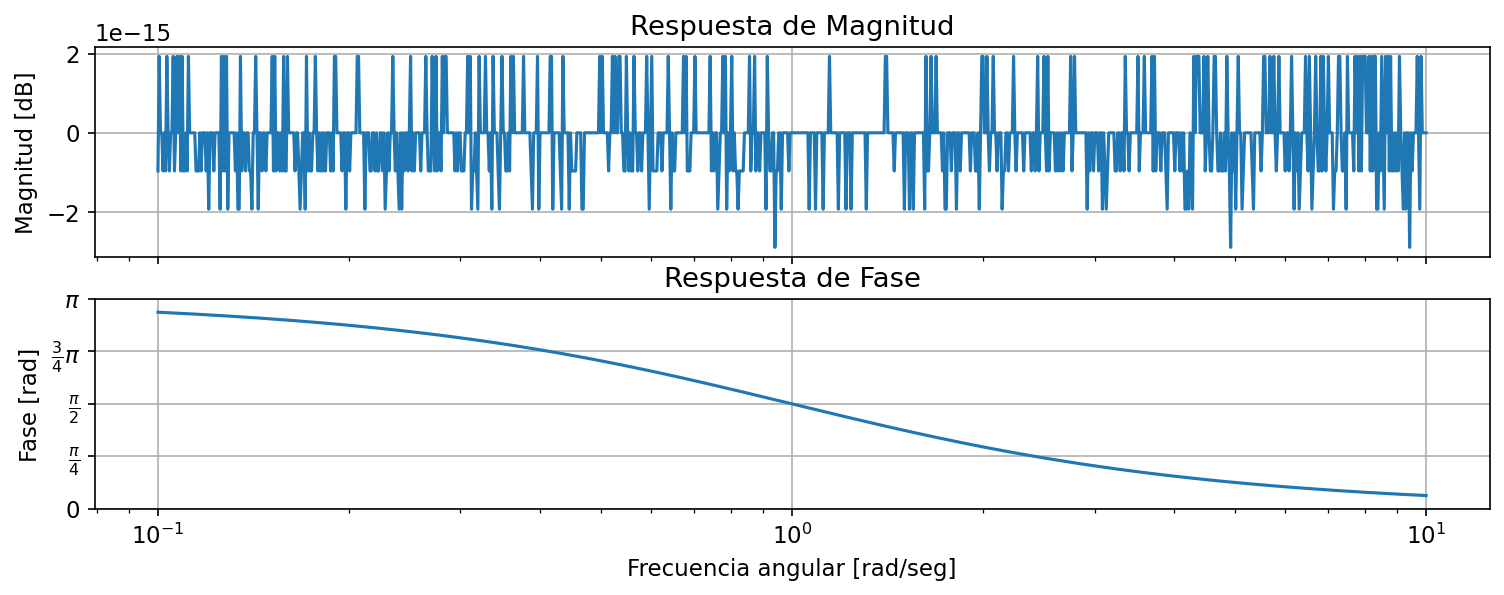

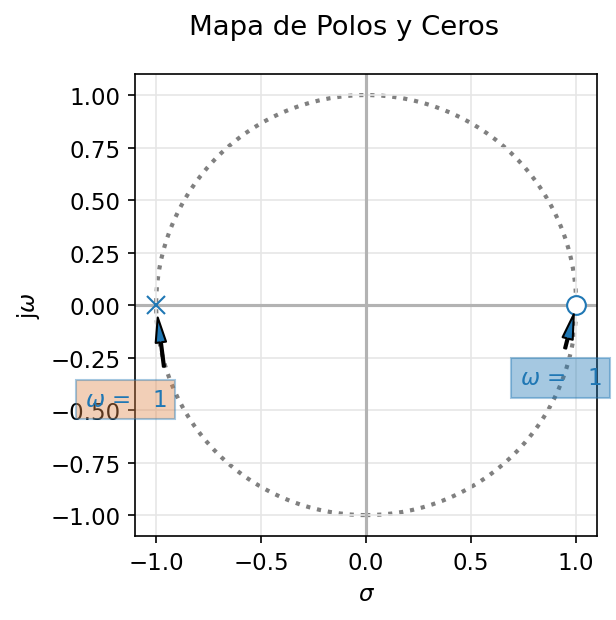

In [7]:
# Bode: módulo y fase (sin ajuste de escala)
# Se observa ruido numérico del orden de 1e-15 dB en la magnitud,
# producto de la precisión de punto flotante.
_, axes_hdl = bodePlot(H_norm)

# Polos y ceros
_ = pzmap(H_norm, annotations=True)

En el gráfico de magnitud anterior se observa un **ruido numérico** del orden de $10^{-15}$ dB. Esto se debe a la precisión finita del punto flotante: matemáticamente $|H(j\omega)| = 1$ exacto, pero numéricamente hay pequeñas desviaciones del orden de la máquina ($\approx 10^{-16}$). Para visualizar correctamente, se ajusta la escala del eje de magnitud a $[-3, 3]$ dB:


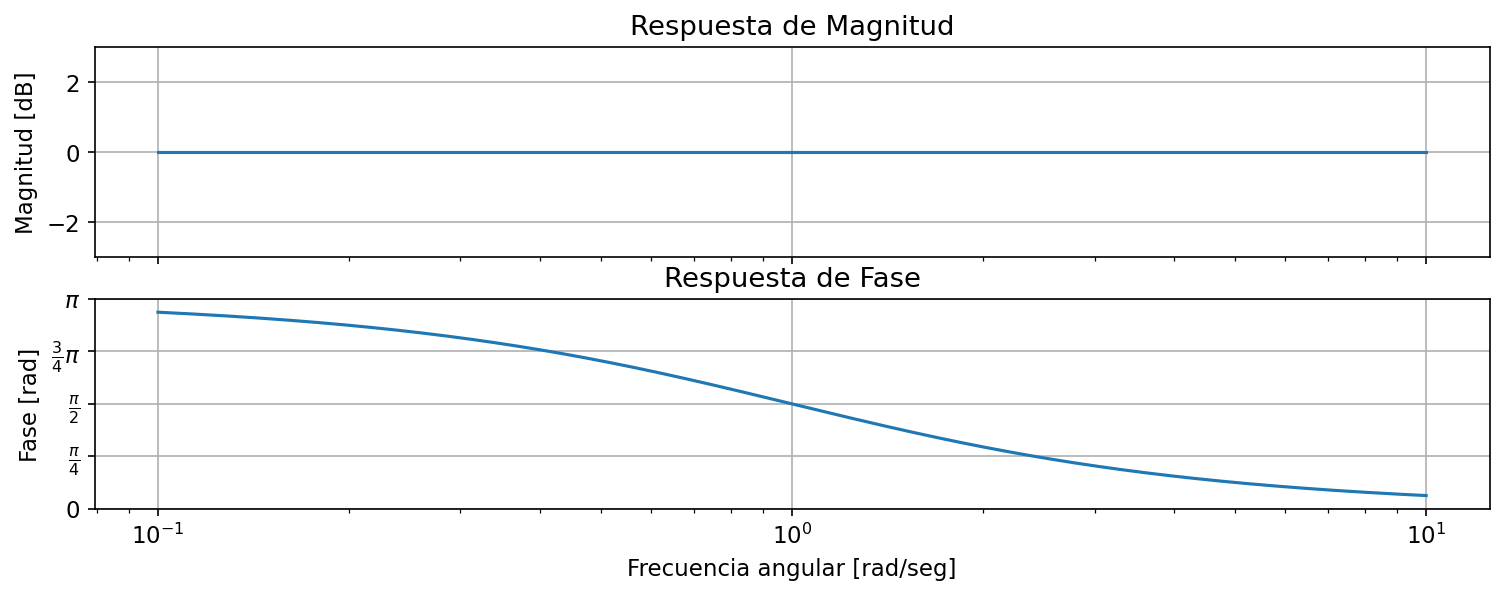

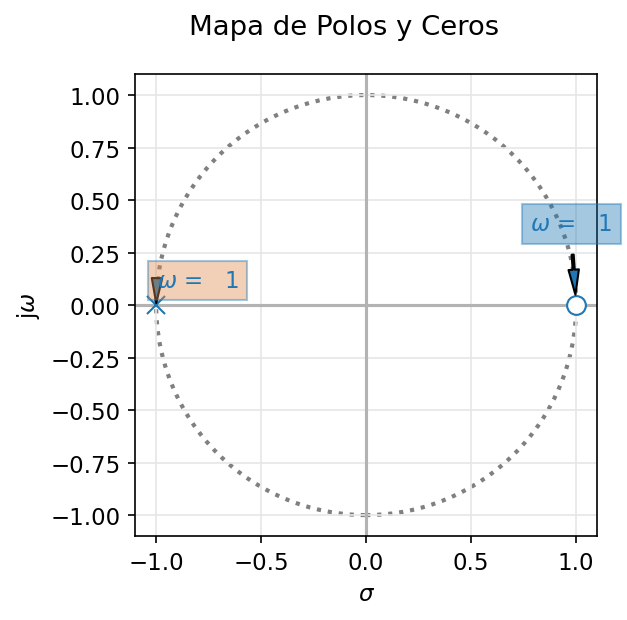

In [8]:
# Bode con escala ajustada: forzamos ylim en [-3, 3] dB para que
# el ruido numérico (1e-15 dB) no distorsione la visualización.
_, axes_hdl = bodePlot(H_norm)
plt.sca(axes_hdl[0])
plt.ylim([-3, 3])

_ = pzmap(H_norm, annotations=True)

***

## Punto 5 — Red normalizada

A partir de la normalización del Punto 3 ($\Omega_z = R_3$, $\Omega_\omega = \frac{1}{R_3 C}$), el circuito normalizado que implementa la transferencia $H(s') = \frac{s'-1}{s'+1}$ tiene:

$$R_3' = 1 \;\Omega \qquad C' = 1 \;\text{F}$$

> **Nota:** Como $R_2 = R_1$ se cancelan en la transferencia, sus valores normalizados no quedan determinados por la normalización — solo se requiere que $R_1' = R_2'$. Por conveniencia de diseño, **elegimos** $R_1' = R_2' = 1$ (lo que implica $R_1 = R_2 = R_3$ en el circuito original).

$$R_1' = R_2' = R_3' = 1 \;\Omega \qquad C' = 1 \;\text{F}$$

El esquemático es idéntico al circuito original de la consigna, con todos los componentes unitarios. Se muestra en la simulación LTSpice del punto siguiente.


***

## Punto 6 — Simulación en LTSpice

Se simula el circuito normalizado en LTSpice para verificar la respuesta en frecuencia.

### Esquemático

<img src="./img/p6_ltspice_circuito.png" width="600" />

El circuito utiliza los componentes normalizados ($R_1' = R_2' = R_3' = 1\;\Omega$, $C' = 1\;\text{F}$) y un opamp ideal. La directiva `.ac dec 100 0.001 100` barre en frecuencia de 1 mHz a 100 Hz.

### Respuesta en frecuencia

<img src="./img/p6_ltspice_bode.png" width="600" />

#### Puntos notables

- **Magnitud (línea sólida):** se mantiene en $\approx 0$ dB para todo el rango de frecuencia, variando solo en el orden de los mdB. Esto confirma $|H(j\omega)| = 1$ obtenido analíticamente en $\mathbf{(8)}$.

- **Fase (línea punteada):**
  - En $f \to 0$: la fase es $180°$, consistente con $H(0) = -1$ y con $\mathbf{(13)}$ evaluada en $\omega = 0$.
  - En $f_0 = \frac{1}{2\pi} \approx 0.159$ Hz ($\omega_0 = 1$ rad/s): la fase cruza por $90°$.
  - En $f \to \infty$: la fase tiende a $0°$, consistente con $\mathbf{(13)}$ para $\omega \to \infty$.

#### Comparación con los resultados anteriores

Los resultados de LTSpice son consistentes con:
- El **cálculo analítico** (Punto 1): $|H| = 1$ y $\phi = \pi - 2\arctan(\omega R_3 C)$.
- La **simulación en Python** (Punto 4): mismo comportamiento de módulo constante y fase monótonamente decreciente de $180°$ a $0°$.
- La única diferencia es que LTSpice muestra el eje de frecuencia en **Hz** mientras que Python usa **rad/s**, relacionados por $f = \omega / 2\pi$.

***

## Bonus — Verificación simbólica con SymPy

Se verifican los resultados de los incisos 1 y 3 mediante simulación simbólica.

### Verificación del Punto 1 — Transferencia, módulo y fase


In [9]:
# Variables simbólicas
s = sp.Symbol('s', complex=True)
w = sp.Symbol('w', real=True, positive=True)
R1, R2, R3, C = sp.symbols('R1 R2 R3 C', positive=True)
Vi, Vx, Vo = sp.symbols('Vi Vx Vo')

# Ecuaciones del circuito (1) y (2)
eq1 = sp.Eq((Vi - Vx) / R1, (Vx - Vo) / R2)
eq2 = sp.Eq((Vi - Vx) * s * C, Vx / R3)

# Resolver para Vx y Vo en función de Vi
sol = sp.solve([eq1, eq2], [Vx, Vo])

# Transferencia H(s) = Vo / Vi
H_general = sp.simplify(sol[Vo] / Vi)

print_latex(a_equal_b_latex_s(r'\frac{V_o}{V_i}', H_general))


<IPython.core.display.Math object>

In [10]:
# Caso particular: R2/R1 = 1 → R2 = R1
H_ap_sym = sp.simplify(H_general.subs(R2, R1))

print_latex(a_equal_b_latex_s(r'\frac{V_o}{V_i}\bigg|_{R_2=R_1}', H_ap_sym))


<IPython.core.display.Math object>

In [11]:
# Verificación del módulo: |H(jw)| = 1
H_jw = H_ap_sym.subs(s, sp.I * w)
modulo_cuadrado = sp.simplify(sp.Abs(H_jw)**2)

print_latex(a_equal_b_latex_s(r'|H(j\omega)|^2', modulo_cuadrado))


<IPython.core.display.Math object>

In [12]:
# Verificación de la fase: arg(H(jw))
fase = sp.arg(H_jw)
fase_simplificada = sp.simplify(fase)

print_latex(a_equal_b_latex_s(r'\angle H(j\omega)', fase_simplificada))

# Evaluar en puntos notables
print(f'\nw → 0:  fase = {sp.limit(fase, w, 0)}')
print(f'w → ∞:  fase = {sp.limit(fase, w, sp.oo)}')


<IPython.core.display.Math object>


w → 0:  fase = pi
w → ∞:  fase = 0


### Verificación del Punto 3 — Transferencia normalizada


In [13]:
# Verificación: sustituir s = s'*w0 en H(s) con R2=R1
# debe dar H(s') = (s'-1)/(s'+1)

s_prime = sp.Symbol("s'", complex=True)
w0_sym = 1 / (R3 * C)

# H(s) con R2=R1
print_subtitle('H(s) con R2 = R1')
print_latex(a_equal_b_latex_s('H(s)', H_ap_sym))

# Sustituir s = s' * w0
H_norm_sym = H_ap_sym.subs(s, s_prime * w0_sym)
H_norm_sym = sp.simplify(H_norm_sym)

print_subtitle("Sustituyendo s = s' · ω₀ = s' · 1/(R₃C)")
print_latex(a_equal_b_latex_s("H(s')", H_norm_sym))


#### H(s) con R2 = R1

<IPython.core.display.Math object>

#### Sustituyendo s = s' · ω₀ = s' · 1/(R₃C)

<IPython.core.display.Math object>

***

## Bonus — Comparación con el Ejercicio 7 de la Guía de TPs

### Circuito del Ejercicio 7

<img src="./img/ej7_circuito_consigna.png" width="400" />

---

### Resolución manuscrita

Originales: `ej7_hoja_1.jpg` a `ej7_hoja_4.jpg` en [img/](./img/)

<img src="./img/ej7_hoja_1.jpg" width="450" />

<img src="./img/ej7_hoja_2.jpg" width="450" />

<img src="./img/ej7_hoja_3.jpg" width="450" />

<img src="./img/ej7_hoja_4.jpg" width="450" />


### Desarrollo

El circuito del ejercicio 7 tiene:
- $R_A$ de $V_1$ a la entrada inversora (-)
- $R_B$ de la entrada inversora (-) a la salida $V_2$ (feedback)
- $Z_1 = R + \frac{1}{sC} = \frac{sCR+1}{sC}$ (R serie C) de $V_1$ a la entrada no inversora (+)
- $Z_2 = R \| \frac{1}{sC} = \frac{R}{sCR+1}$ (R paralelo C) de (+) a GND

---

#### Ecuaciones del circuito

Ley de Kirchhoff de corrientes en (-) con $V_- = V_+$ (opamp ideal):

$$\frac{V_1 - V_x}{R_A} = \frac{V_x - V_2}{R_B} \quad \mathbf{(1)}$$

Divisor en (+):

$$V_x = V_1 \cdot \frac{Z_2}{Z_1 + Z_2} \quad \mathbf{(2)}$$

Sustituyendo $\mathbf{(2)}$ en $\mathbf{(1)}$ y despejando:

$$\frac{V_2}{V_1} = \frac{R_A Z_2 - R_B Z_1}{R_A(Z_1 + Z_2)} \quad \mathbf{(3)}$$

---

#### $Z_1 + Z_2$

$$Z_1 + Z_2 = \frac{sCR+1}{sC} + \frac{R}{sCR+1} = \frac{(sCR+1)^2 + sCR}{sC(sCR+1)} = \frac{s^2C^2R^2 + 3sCR + 1}{sC(sCR+1)} \quad \mathbf{(4)}$$

---

#### Transferencia general

Sustituyendo $\mathbf{(4)}$ en $\mathbf{(3)}$ y simplificando:

$$\frac{V_2}{V_1} = -\frac{R_B}{R_A} \cdot \frac{s^2 - \left(\frac{R_A}{R_B} - 2\right)\frac{1}{RC}\,s + \frac{1}{R^2C^2}}{s^2 + \frac{3}{RC}\,s + \frac{1}{R^2C^2}}$$

Definiendo $\omega_0 = \frac{1}{RC}$:

$$\boxed{\frac{V_2}{V_1} = -\frac{R_B}{R_A} \cdot \frac{s^2 - \left(\frac{R_A}{R_B} - 2\right)\omega_0\,s + \omega_0^2}{s^2 + 3\omega_0\,s + \omega_0^2}}$$

---

#### Caso pasa-todo: $R_A = 5R_B$

$$\frac{V_2}{V_1} = -\frac{1}{5} \cdot \frac{s^2 - 3\omega_0\,s + \omega_0^2}{s^2 + 3\omega_0\,s + \omega_0^2}$$

Con $\omega_0 = \frac{1}{RC}$ y $Q = \frac{1}{3}$ (sobreamortiguado, $Q < \frac{1}{2}$ → polos y ceros reales).

**Ceros:** $s_{z_{1,2}} = \frac{\omega_0(3 \pm \sqrt{5})}{2} \approx +0.382\,\omega_0$ y $+2.618\,\omega_0$

**Polos:** $s_{p_{1,2}} = \frac{\omega_0(-3 \pm \sqrt{5})}{2} \approx -0.382\,\omega_0$ y $-2.618\,\omega_0$

Cada cero es el espejo de su polo: $s_z = -s_p$.

---

#### Análisis por método gráfico (ver página 4 del manuscrito)

**Módulo:** Por el método gráfico podemos esperar que el módulo sea constante (no olvidar $K = -R_B/R_A = -1/5$), ya que los polos están a la misma distancia $d_p$ del eje $j\omega$ que los ceros $d_z$, para cualquier frecuencia:

$$|H(j\omega)| = \frac{1}{5} \cdot \frac{d_{z_1} \cdot d_{z_2}}{d_{p_1} \cdot d_{p_2}} = \frac{1}{5} \quad \forall\;\omega$$

**Fase:** Desde ya tendrá un $\pi$ agregado por el signo negativo de $-R_B/R_A$. Luego, para $\omega \to 0$ el aporte de los ceros da $360°$ (equivalente a $0°$) y vemos un aporte de $0°$ de los polos. Para $\omega \to \infty$ las contribuciones de los polos y ceros serán $\pi/2$ cada una, haciendo que se anulen; entonces también quedaría solo el $\pi$. Sabiendo que la fase debe tener pendiente negativa, se puede esperar que vaya de $\pi$ a $-\pi$, habiendo recorrido $2\pi$, lo que corresponde para un sistema pasa-todo de **2do orden**.


In [14]:
# Ejercicio 7: pasa-todo de 2do orden (RA=5RB)
# Valores de la guía: R = 1kΩ, C = 1μF → w0 = 1/(RC) = 1000 rad/s
# RA = 5kΩ, RB = 1kΩ

R = 1e3       # 1 kΩ
C_val = 1e-6  # 1 μF
RA = 5e3      # 5 kΩ
RB = 1e3      # 1 kΩ
w0_ej7 = 1 / (R * C_val)  # 1000 rad/s

# H(s) = -RB/RA * (s² - 3*w0*s + w0²) / (s² + 3*w0*s + w0²)
num_ej7 = np.array([-RB/RA, 3*RB/RA*w0_ej7, -RB/RA*w0_ej7**2])
den_ej7 = np.array([1, 3*w0_ej7, w0_ej7**2])

H_ej7 = sig.TransferFunction(num_ej7, den_ej7)

print_subtitle('Ejercicio 7 — Pasa-todo 2do orden')
print(f'w0 = 1/(RC) = {w0_ej7:.0f} rad/s  (f0 = {w0_ej7/(2*np.pi):.1f} Hz)')
print(f'Polos: {H_ej7.poles}')
print(f'Ceros: {H_ej7.zeros}')


#### Ejercicio 7 — Pasa-todo 2do orden

w0 = 1/(RC) = 1000 rad/s  (f0 = 159.2 Hz)
Polos: [-2618.03398875  -381.96601125]
Ceros: [2618.03398875  381.96601125]


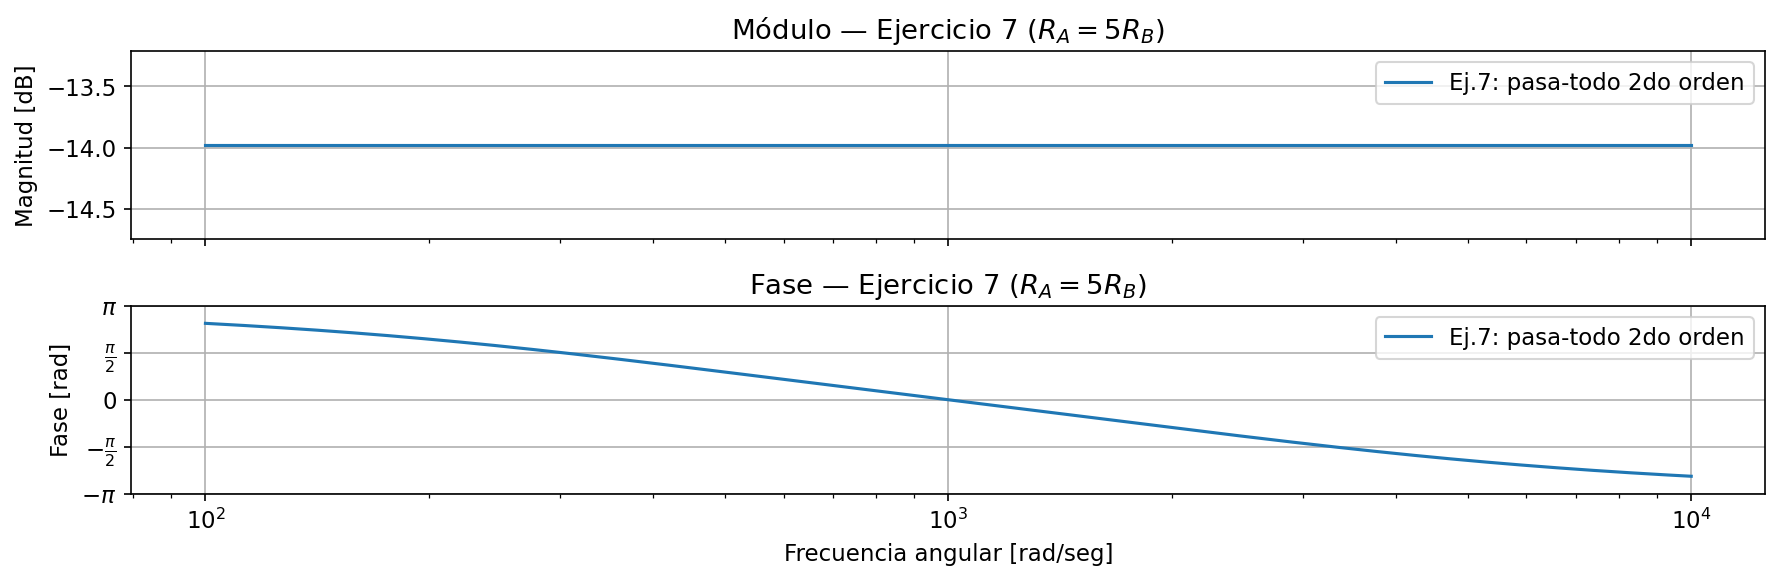

In [15]:
# Bode: módulo y fase
_, axes_hdl = bodePlot(H_ej7, filter_description='Ej.7: pasa-todo 2do orden')
plt.sca(axes_hdl[0])
plt.title('Módulo — Ejercicio 7 ($R_A = 5R_B$)')

plt.sca(axes_hdl[1])
plt.title('Fase — Ejercicio 7 ($R_A = 5R_B$)')

plt.tight_layout()
plt.show()


Los gráficos confirman lo predicho por el método gráfico en el manuscrito (página 4):

- **Módulo:** constante en $-14$ dB $= 20\log_{10}(1/5)$, verificando que $|H(j\omega)| = 1/5\;\forall\;\omega$.
- **Fase:** parte de $180°$, desciende pasando por $0°$ en $\omega_0$, y llega a $-180°$. Excursión total de $2\pi$, consistente con un pasa-todo de **2do orden**.


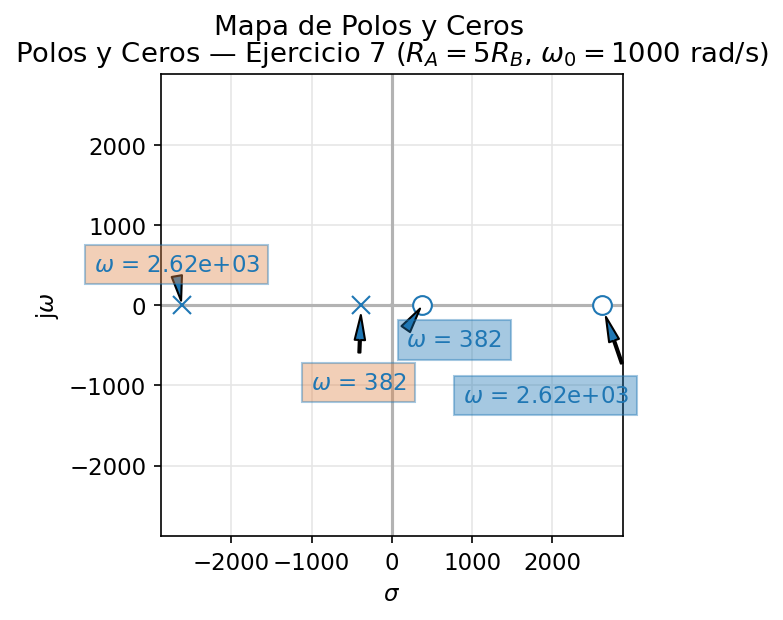

In [16]:
# Polos y ceros
pzmap(H_ej7, annotations=True)
plt.title('Polos y Ceros — Ejercicio 7 ($R_A = 5R_B$, $\\omega_0 = 1000$ rad/s)')
plt.legend().remove()
plt.show()


### Simulación en LTSpice (Ejercicio 7)

Se utilizaron los valores indicados en la guía: $R = 1\,\text{k}\Omega$, $C = 1\,\mu\text{F}$, $R_A = 5\,\text{k}\Omega$, $R_B = 1\,\text{k}\Omega$ ($\omega_0 = 1000$ rad/s, $f_0 \approx 159$ Hz).

#### Esquemático

<img src="./img/ej7_ltspice_circuito.png" width="600" />

#### Respuesta en frecuencia

<img src="./img/ej7_ltspice_bode.png" width="600" />

Los resultados de LTSpice verifican lo obtenido en Python y en el análisis gráfico del manuscrito:

- **Módulo:** constante en $-14$ dB ($= 1/5$) en todo el rango de frecuencia.
- **Fase:** de $180°$ a $-180°$ pasando por $0°$ cerca de $f_0 \approx 159$ Hz, con excursión total de $360°$ (2do orden).


### Comparación: Tarea Semanal 1 vs Ejercicio 7

<div style="font-size: 1.15em;" align="center">

| | **Tarea (1er orden)** | **Ejercicio 7 (2do orden)** |
|:---|:---|:---|
| **Transferencia** | $\frac{s - \omega_0}{s + \omega_0}$ | $-\frac{1}{5} \cdot \frac{s^2 - 3\omega_0 s + \omega_0^2}{s^2 + 3\omega_0 s + \omega_0^2}$ |
| **Orden** | 1 | 2 |
| **Ganancia** | $1$ (unitaria) | $1/5$ (no unitaria) |
| **Polos** | 1 real en $-\omega_0$ | 2 reales en $\omega_0(-3 \pm \sqrt{5})/2$ |
| **Ceros** | 1 real en $+\omega_0$ | 2 reales en $\omega_0(3 \pm \sqrt{5})/2$ |
| **Q** | N/A (1er orden) | $1/3$ (sobreamortiguado) |
| **$\|H\|$** | $1$ ($0$ dB) | $1/5$ ($-14$ dB) |
| **Excursión de fase** | $180°$ ($\pi \to 0$) | $360°$ ($\pi \to 0 \to -\pi$) |
| **Fase en $\omega_0$** | $90°$ | $0°$ |
| **Resistores** | 3 ($R_1, R_2, R_3$) | 4 ($R_A, R_B, R_{Z_1}, R_{Z_2}$) |
| **Capacitores** | 1 ($C$) | 2 ($C_{Z_1}, C_{Z_2}$) |
| **Opamps** | 1 | 1 |
| **Condición pasa-todo** | $R_2 = R_1$ | $R_A = 5R_B$ |

</div>

**Similitudes:** Ambos son pasa-todo (módulo constante, solo modifican la fase). 
Ambos tienen simetría polo-cero respecto al eje imaginario ($s_z = -s_p$). 
Ambos usan un solo opamp.

**Diferencias:** El ejercicio 7 es de 2do orden (recorre $2\pi$ de fase vs $\pi$), 
tiene ganancia no unitaria ($1/5$), requiere más componentes (4 resistores y 2 capacitores vs 3 resistores y 1 capacitor), 
y necesita una relación específica $R_A = 5R_B$ para ser pasa-todo. 
La tarea solo necesita $R_2 = R_1$ para ser pasa-todo, y la ganancia resulta unitaria sin condiciones adicionales.
